In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.utils as vutils

In [6]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import plotly
import plotly.graph_objects as go

In [7]:
%matplotlib inline

In [10]:
batch_size = 128
latent_size = 20
epochs = 20
learning_rate = 1e-3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_loader = DataLoader(
    datasets.MNIST('../data', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True)


In [13]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU(),
            nn.Linear(400, 200),
            nn.ReLU(),
            nn.Linear(200, latent_size * 2)  # 2 for mean and variance
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 200),
            nn.ReLU(),
            nn.Linear(200, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()  # Sigmoid activation to output probabilities
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Flatten input images
        x = x.view(-1, 784)
        
        # Encode
        h = self.encoder(x)
        mu, logvar = torch.chunk(h, 2, dim=1)
        
        # Reparameterization trick
        z = self.reparameterize(mu, logvar)
        
        # Decode
        x_recon = self.decoder(z)
        
        return x_recon, mu, logvar

In [14]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

def loss_function(recon_x, x, mu, logvar):
    BCE = nn.BCELoss(reduction='sum')(recon_x, x.view(-1, 784))
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [15]:
def train(model, optimizer, train_loader, epochs):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()
            recon_batch, mu, logvar = model(data)
            loss = loss_function(recon_batch, data, mu, logvar)
            loss.backward()
            total_loss += loss.item()
            optimizer.step()

            if batch_idx % 100 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Batch {batch_idx}, Loss: {loss.item()/len(data)}")

        print(f"====> Epoch {epoch+1}/{epochs}, Average Loss: {total_loss / len(train_loader.dataset)}")

# train(model, optimizer, train_loader, epochs)

In [16]:
# torch.save({'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(),}, 'vae_model.pth')
checkpoint = torch.load('vae_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

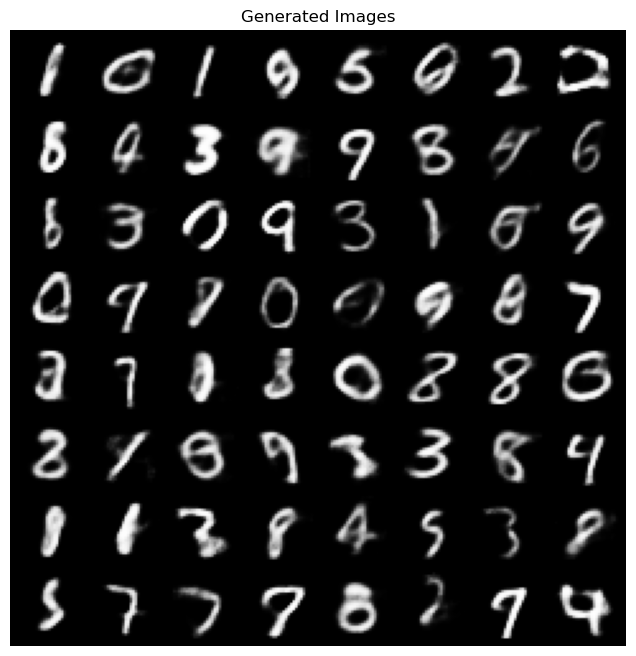

In [17]:
def generate_samples(model, num_samples):
    with torch.no_grad():
        z = torch.randn(num_samples, latent_size).to(device)
        samples = model.decoder(z).cpu()
        samples = samples.view(-1, 1, 28, 28)
        return samples

# Generate and visualize samples
samples = generate_samples(model, 64)
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generated Images")
plt.imshow(np.transpose(vutils.make_grid(samples, padding=2, normalize=True).cpu(), (1, 2, 0)))
plt.show()


In [105]:
with open('h_end.npy', 'rb') as file:
    ends = torch.tensor(np.load(file)/255., dtype=torch.float32)

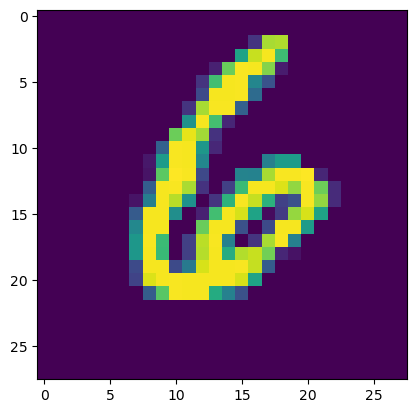

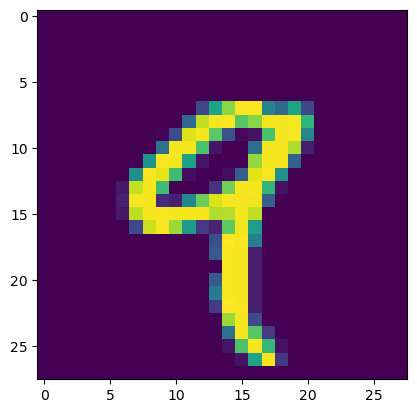

In [106]:
plt.imshow(ends[0])
plt.show()
plt.imshow(ends[1])

In [107]:
with torch.no_grad():
    embeds = model.encoder(ends.view(-1, 784))

In [108]:
def h_embed(t):
    with torch.no_grad():
        latent = (1-t)*embeds[0:1]+t*embeds[1:2]
        mu, logvar = torch.chunk(latent, 2, dim=1)
        z = model.reparameterize(mu, logvar)
        return model.decoder(z).cpu().view(-1, 1, 28, 28)[0,0]
    

In [109]:
ts = np.linspace(0, 1, 100)
hs = [h_embed(t) for t in ts]

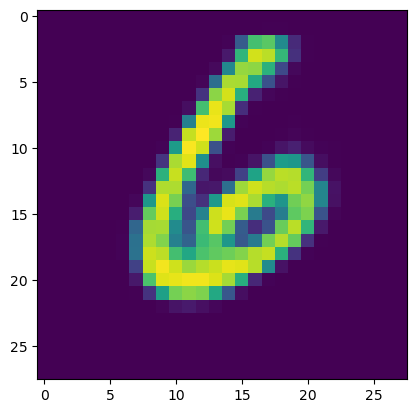

In [110]:
fig, ax = plt.subplots()
im = ax.imshow(hs[0], cmap='viridis', interpolation='nearest')

def init():
    im.set_data(hs[0])
    return [im]

def upd(i):
    im.set_data(hs[i])
    return [im]

ani = FuncAnimation(fig, upd, frames=range(len(ts)),
                    init_func=init, blit=True)

In [111]:
with open('hs69.npy', 'wb') as f:
    np.save(f, np.array(hs))



In [112]:
from IPython.display import HTML
HTML(ani.to_html5_video())